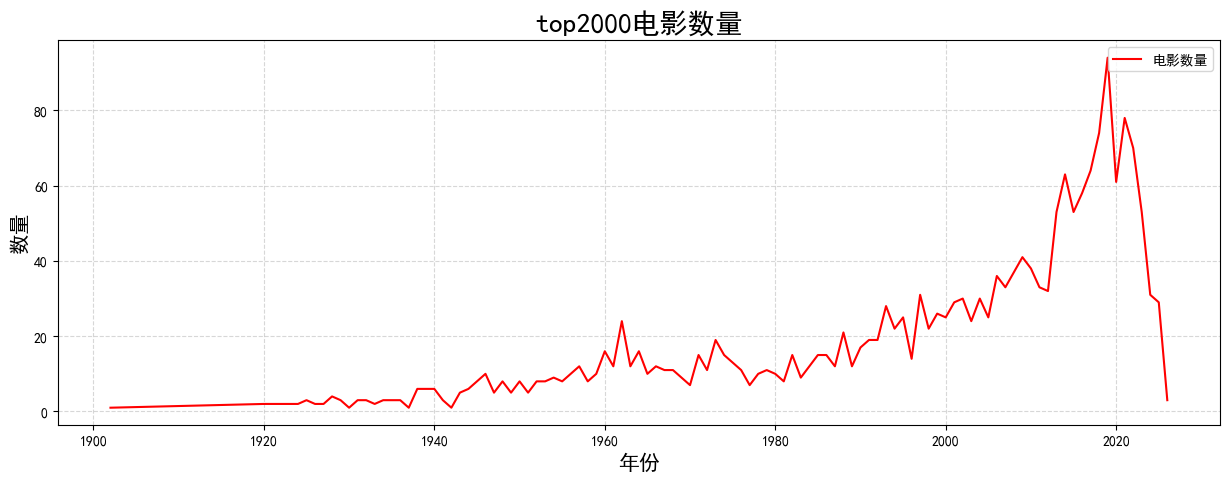

In [76]:
import pandas
import matplotlib.pyplot as mp
mp.rcParams['font.sans-serif'] = ['SimHei']

df = pandas.read_csv("tmdb.csv")
first_df = df.groupby("年份")["电影名"].count()
years = first_df.index.tolist()
counts = first_df.values.tolist()

mp.figure(figsize=(15,5))
mp.plot(years,counts,label="电影数量",color="red")
mp.legend(loc="upper right")
mp.title("top2000电影数量",fontsize=20)
mp.xlabel("年份",fontsize=15)
mp.ylabel("数量",fontsize=15)
mp.grid(linestyle='--',alpha=0.5)
mp.savefig('years.png')
mp.show()


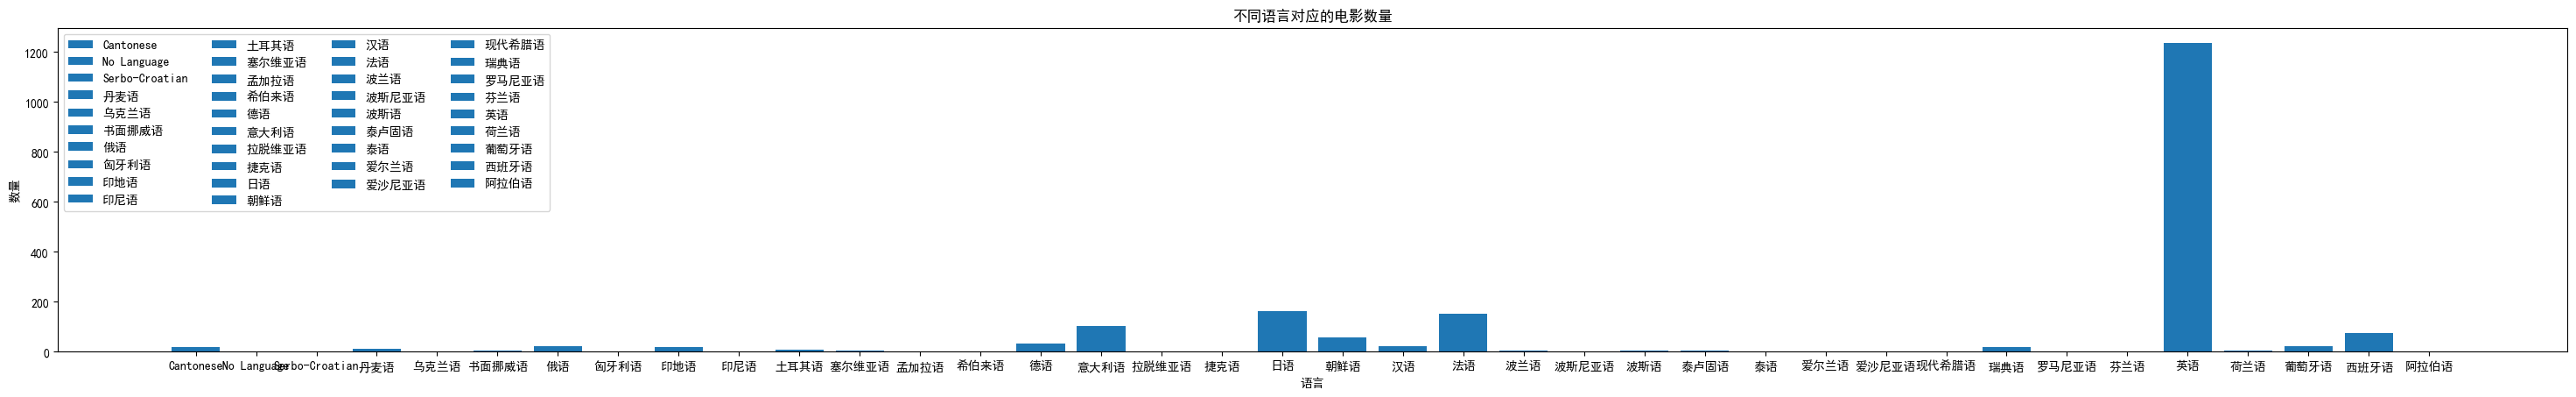

In [75]:
import pandas
import matplotlib.pyplot as mp
mp.rcParams['font.sans-serif'] = ['SimHei']

df = pandas.read_csv("tmdb.csv")
second_df = df.groupby("语言")["电影名"].count()
languages = second_df.index.tolist()
counts = second_df.values.tolist()

fig, ax = mp.subplots()
fig.set_figwidth(37)
ax.bar(languages, counts, label=languages)
ax.set_ylabel('数量')
ax.set_xlabel('语言')
ax.set_title('不同语言对应的电影数量')
ax.legend(ncol=4)

fig.savefig('languages.png')
mp.show()


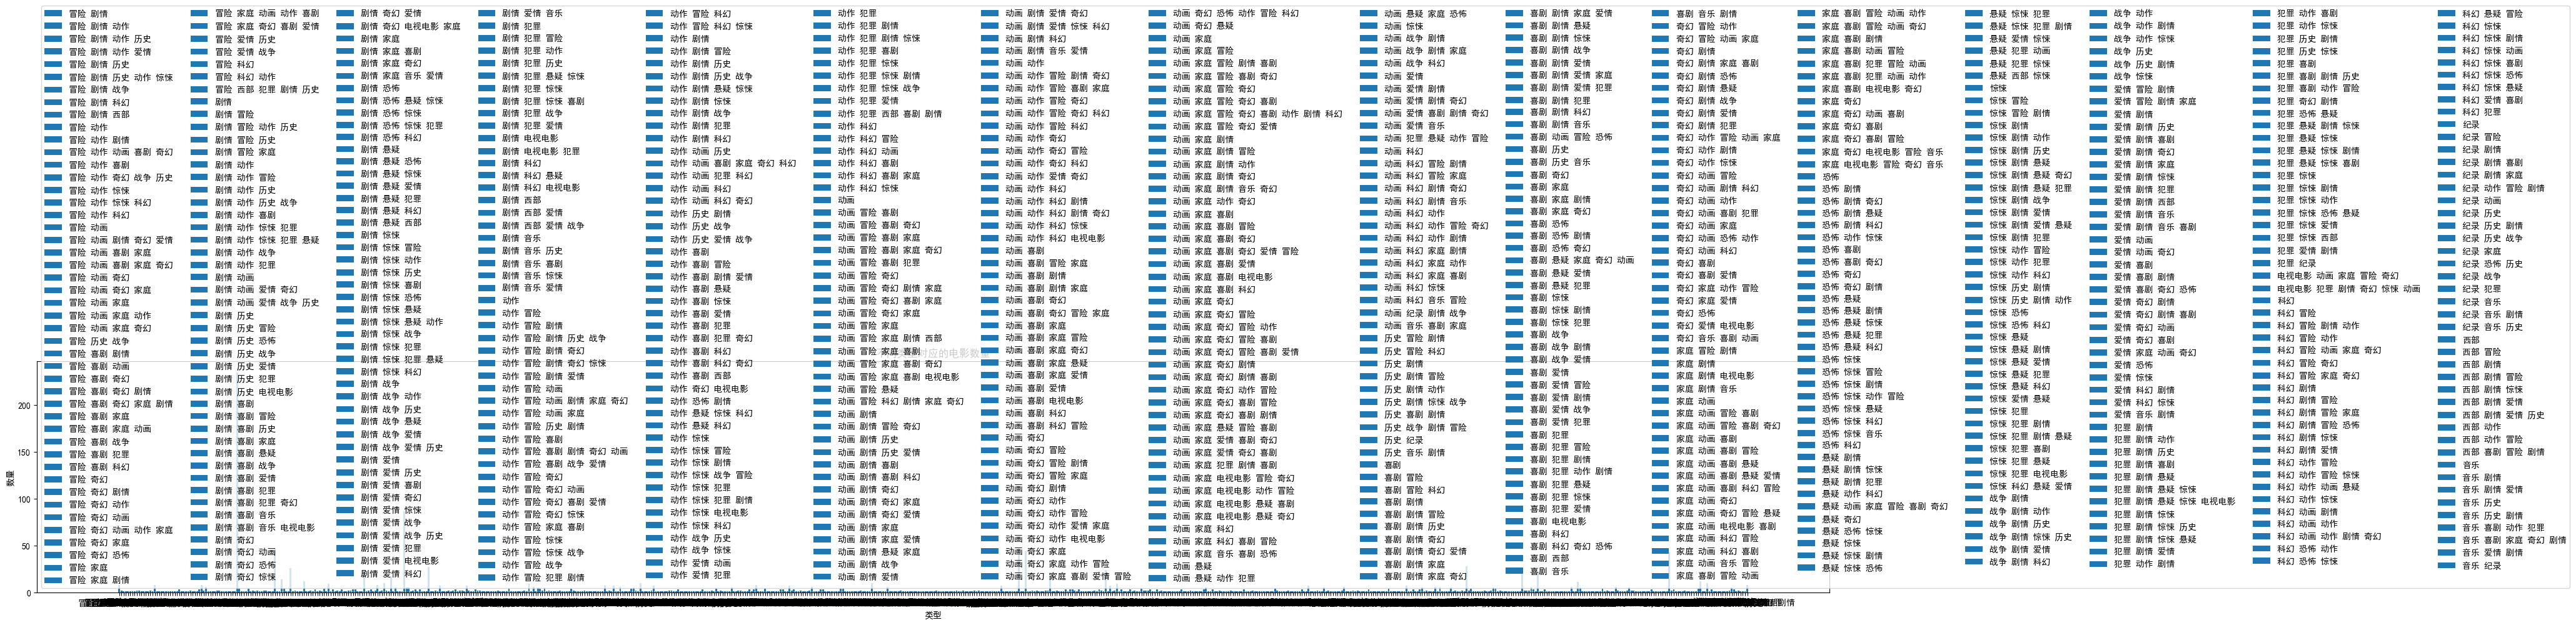

In [78]:
import pandas
import matplotlib.pyplot as mp
mp.rcParams['font.sans-serif'] = ['SimHei']

df = pandas.read_csv("tmdb.csv")
third_df = df.groupby("类型")["电影名"].count()
types = third_df.index.tolist()
counts = third_df.values.tolist()

fig, ax = mp.subplots()
fig.set_figwidth(37)
ax.bar(types, counts, label=types)
ax.set_ylabel('数量')
ax.set_xlabel('类型')
ax.set_title('不同类型对应的电影数量')
ax.legend(ncol=16)

fig.savefig('types.png')
mp.show()


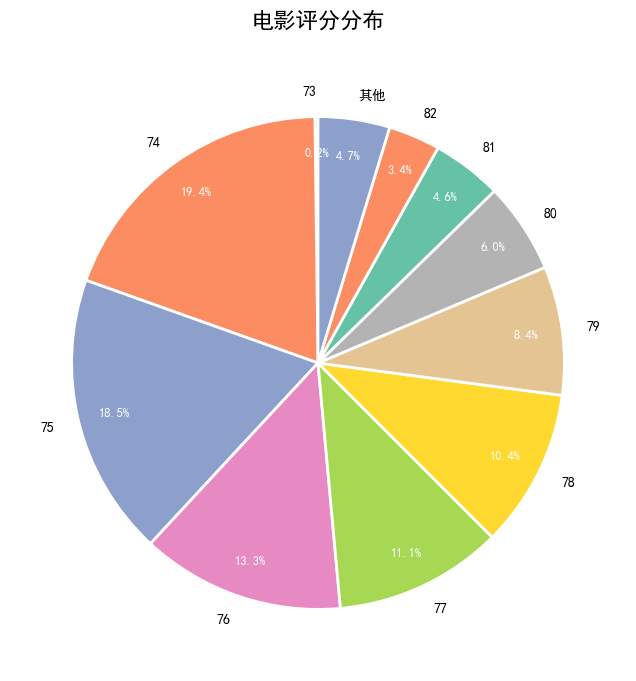

In [90]:
import pandas
import matplotlib.pyplot as mp
mp.rcParams['font.sans-serif'] = ['SimHei']

df = pandas.read_csv("tmdb.csv")
fourth_df = df.groupby("评分")["电影名"].count().sort_index()

# 只显示主要评分，避免过于密集
top_n = 10
if len(fourth_df) > top_n:
    top_scores = fourth_df.head(top_n)
    other_count = fourth_df.iloc[top_n:].sum()
    scores = top_scores.index.tolist() + ["其他"]
    counts = top_scores.values.tolist() + [other_count]
else:
    scores = fourth_df.index.tolist()
    counts = fourth_df.values.tolist()

fig, ax = mp.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(counts,
                                   labels=scores,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   pctdistance=0.85,
                                   wedgeprops=dict(edgecolor='w', linewidth=2),
                                   colors=mp.cm.Set2.colors)

# 设置百分比文字样式
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# 设置标签文字样式
for text in texts:
    text.set_fontsize(10)

ax.set_title("电影评分分布", fontsize=16, fontweight='bold', pad=20)

# 保存和显示
mp.savefig('score_distribution.png', dpi=300, bbox_inches='tight')
mp.show()
